---
---
# <h1 align="center">TECHNIQUES OF ARTIFICIAL INTELLIGENCE</h1>
<h2 align="center">VUB - Applied Computer Science</h2>
<h3 align="center"><b>PROJECT TOPIC : Breast cancer data</b></h3>
<hr>
<hr>

**The dataset is composed by patient's micros.<br>
A line of the dataset is a micro.<br>
Each patient has several micros but each micro belongs to one patient.<br>
Each micro has 150 features plus the associated label cancerous or not and the ID of the patient to which it belongs.<br>
Since each subject in the dataset has multiple micros, we assume that all micros from the same subject have the same label.**

---
## TASK 1: Predict micro's label</h2>

---

**The goal of task 1 is to classify micros as benign or malignant.<br>
So the goal is to build a ML model thanks to collected data that allows us to predict as well as possible micros' labels on unseen data.**

### DATA FILE IMPORT

In [1]:
import pandas as pd

In [2]:
# Import the dataset as a pandas dataframe
file_path = 'Reduced Features for TAI project.xlsx' # File path
data = pd.read_excel(file_path)
data

,Patient ID,original_shape_Elongation,original_firstorder_Kurtosis,original_firstorder_Skewness,wavelet-LHL_glrlm_RunVariance,wavelet2-LHL_gldm_LargeDependenceEmphasis,wavelet2-LLH_gldm_LargeDependenceEmphasis,wavelet-LHL_gldm_LargeDependenceEmphasis,wavelet2-LHL_gldm_DependenceVariance,wavelet2-LHL_glrlm_RunVariance,...,wavelet-LLL_glszm_LargeAreaLowGrayLevelEmphasis,wavelet2-HHH_firstorder_RootMeanSquared,wavelet2-LLH_firstorder_Kurtosis,wavelet-HHL_glcm_Imc2,wavelet2-LHH_firstorder_RobustMeanAbsoluteDeviation,original_shape_SphericalDisproportion,wavelet2-HHL_glcm_Idmn,wavelet2-LHH_firstorder_RootMeanSquared,wavelet2-HLL_firstorder_Maximum,Label
0,1,0.661690,2.817688,0.769536,7.257078,3381.734540,3715.077716,3546.818663,634.748331,6.682128,...,4005.210235,0.408974,2.949406,0.231474,0.473838,1.572473,0.983853,0.875074,142.866201,0
1,1,0.750849,2.084800,0.442780,3.137745,2653.808184,1443.697357,2297.305200,616.359443,4.095513,...,32.058217,0.282009,2.790798,0.010531,0.401979,1.178144,0.905124,0.696716,21.693040,0
2,1,0.619781,2.590759,0.384512,7.005413,3551.125894,3568.780890,3342.865490,426.661231,8.535867,...,63032.030205,0.442902,3.211156,0.276207,0.446076,1.615550,0.993054,0.832938,163.039718,0
3,2,0.388733,2.932863,0.738215,2.178815,1564.039548,1370.065913,1839.930320,318.122386,1.939531,...,147.649047,0.330143,3.054401,0.023870,0.399957,1.306885,0.911141,0.727764,22.979554,0
4,2,0.820531,2.814081,0.773252,1.316850,1377.981413,1005.602230,1164.799257,325.473446,1.726775,...,65.872763,0.278449,2.074076,0.016973,0.350459,1.165727,0.906515,0.606753,24.490320,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3557,96,0.225097,3.145095,0.887252,0.507042,113.521739,63.289855,158.304348,21.194707,0.420766,...,22.156250,0.148424,2.383944,0.025038,0.236198,1.412431,0.924402,0.649229,27.270149,1
3558,96,0.503842,2.484876,0.655281,4.641217,2475.349595,2771.461923,2684.326511,574.123960,4.591888,...,450.172765,0.403421,3.311709,0.546492,0.400437,1.494975,0.992242,0.734152,288.610250,1
3559,96,0.454726,3.363199,1.026167,6.014596,3310.430153,1430.379898,3536.925043,548.184562,5.595325,...,336.564815,0.114790,3.124013,0.028680,0.319474,1.609656,0.895515,0.566488,14.823064,1
3560,96,0.624101,2.205947,0.349004,1.626775,921.056338,280.690141,1045.957746,148.842690,1.583895,...,14.416448,0.131801,2.174953,0.072674,0.254557,1.280580,0.895171,0.542009,15.171972,1


### DATA PREPROCESSING

**Data preprocessing is a way to clean the data set.**<br>
For example, we check for missing values.<br>
Indeed, many algorithms do not know how to deal with missing values and this can affect the proper functioning of the model.<br>
Additionally, if the missing values are not random and are related to a certain characteristic or behavior, this can introduce bias into the data analysis and lead to erroneous conclusions.<br>

In [3]:
columns_to_keep = data.columns[1:-1]
# Features
X = data[columns_to_keep]
# Labels
Y = data['Label']

In [4]:
# Creates an empty list to store features with missing values
not_null = []

# Iterates through all features
for feature in columns_to_keep:
    # Checks if there are any missing (NaN) values in the current feature
    if data[feature].isnull().sum() != 0:
        # If there are missing values, adds the feature to the list not_null
        not_null.append(feature)

print('Space X :')

# Checks if the list not_null is empty, if not_null is empty not not_null returns False
if not not_null:
    print('No NaN values in features.')
else:
    print('NaN values are present in the following features:', not_null)

Space X :
No NaN values in features.


In [5]:
print('Space Y:')

# Checks if there are any missing (NaN) values in the labels (Y)
if Y.isnull().sum() == 0:
    print('No Nan values in labels.')
else:
    print('Nan values in labels.')

Space Y:
No Nan values in labels.


### DATA VISUALIZATION

In [6]:
import matplotlib.pyplot as plt

/home/amandine/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


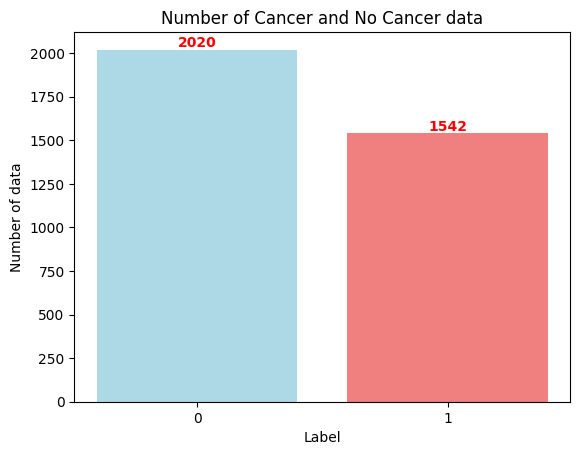

In [7]:
# Counts the number of occurrences of each posible value of the 'Label' column
count_labels = data['Label'].value_counts()
# Creates a bar plot to display the number of data for each label class
plt.bar(count_labels.index, count_labels.values, color=['lightblue', 'lightcoral'])
# Adds legend and title
plt.xlabel('Label')
plt.ylabel('Number of data')
plt.title('Number of Cancer and No Cancer data')

# Adds the values of each bar above the corresponding bars
for i, value in enumerate(count_labels.values):
    plt.text(i, value + 15, str(value), ha='center', color="red", fontweight="bold")

# Sets the locations of the ticks on the x-axis
plt.xticks(count_labels.index)
# Displays the plot
plt.show()

The data set includes 2020 begnin micros and 1542 malignant micros.

In [ ]:
# Determines the majority class label
def majority_vote(labels):
    # Counts the occurrences of label cancer (= 1)
    count_cancer = sum(labels == 1)
    # Counts the occurrences of label no cancer (= 0)
    count_no_cancer = sum(laL'optimisation des hyperparamètres a été réalisée avec la méthode RandomizedSearchCV.bels == 0)
    # Checks if the count of 'cancer' label occurrences is greater than the count of 'no cancer' label occurrences
    if count_cancer > count_no_cancer:
        return 1
    else:
        return 0

In [9]:
# Groups the data by 'Patient ID'
grouped_by_patient = data.groupby('Patient ID')

new_data = []

# Iterates through each group, where each group represents the data for a specific patient
for patient_id, patient in grouped_by_patient:
    # Calculates the majority label for the patient's data
    majority_label = majority_vote(patient['Label'])
    # Appends a dictionary containing the patient's ID and the majority label to the new_data list
    new_data.append({'Patient ID': patient_id, 'Label (majority vote)': majority_label})

# Creates a new DataFrame from the list of dictionaries containing patient IDs and their majority labels
data_df = pd.DataFrame(new_data)

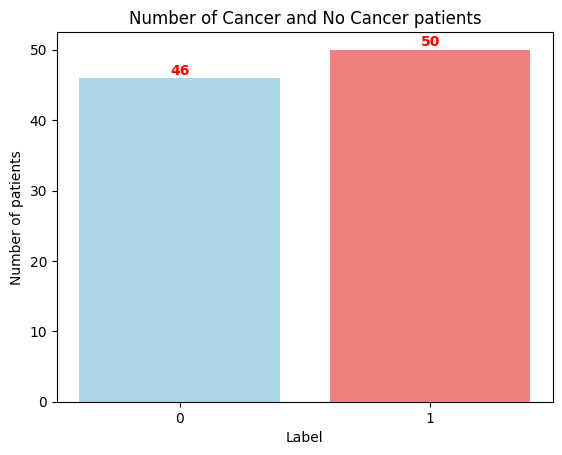

In [10]:
# Counts the number of patients unaffected by cancer
no_cancer = len(data_df[data_df['Label (majority vote)'] == 0])
# Counts the number of patients affected by cancer
cancer = len(data_df[data_df['Label (majority vote)'] == 1])

labels = ['0', '1']
values = [no_cancer, cancer]

# Creates a bar plot to display the number of patient for each label class
plt.bar(labels, values, color=['lightblue', 'lightcoral'])
# Adds legend and title
plt.xlabel('Label')
plt.ylabel('Number of patients')
plt.title('Number of Cancer and No Cancer patients')

# Adds the values of each bar above the corresponding bars
for i, value in enumerate(values):
    plt.text(i, value + 0.5, str(value), ha='center', color="red", fontweight="bold")

# Displays the plot
plt.show()

<u>**Interpretation**</u>

We can see that the number of non-cancerous patient is quite equivalent to the number of cancerous patient. <br>
We have a balanced set given patients and it's good.<br>

If we talk in terms of micros, there's an imbalance: there are more non-cancerous micros than cancerous ones.

### DATA SEPARABILITY

In [11]:
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np

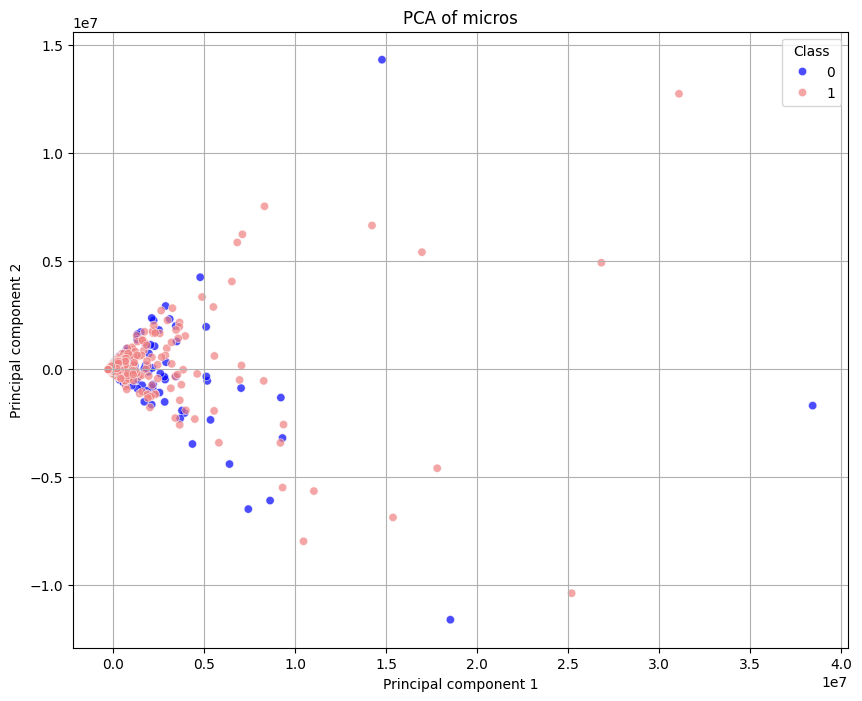

,PC1,PC2
original_shape_Elongation,-0.009595,-0.001027
original_firstorder_Kurtosis,-0.034296,0.051307
original_firstorder_Skewness,-0.051914,0.040384
wavelet-LHL_glrlm_RunVariance,1.144488,-0.138812
wavelet2-LHL_gldm_LargeDependenceEmphasis,393.359905,10.065062
...,...,...
wavelet2-LHH_firstorder_RobustMeanAbsoluteDeviation,-0.012623,-0.005158
original_shape_SphericalDisproportion,0.072082,0.025527
wavelet2-HHL_glcm_Idmn,0.002930,-0.004083
wavelet2-LHH_firstorder_RootMeanSquared,-0.035545,-0.012804


In [12]:
# PCA
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(X)
pca_df = pd.DataFrame(data=principalComponents, columns=['principal_component_1', 'principal_component_2'])
pca_df['class'] = Y

# Plot PCA results
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x ='principal_component_1',
    y ='principal_component_2',
    hue ='class',
    palette = {1: 'lightcoral', 0: 'blue'},
    data = pca_df,
    alpha = 0.7
)
plt.title('PCA of micros')
plt.xlabel('Principal component 1')
plt.ylabel('Principal component 2')
plt.legend(title='Class')
plt.grid(True)
plt.show()

# Display correlations between original features and principal components
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loading_df = pd.DataFrame(loadings, columns=['PC1', 'PC2'], index=X.columns)
loading_df

<u>**Interpretation**</u>

I used PCA to reduce the dimensionality of my data set and visualize the data projected onto the first two principal components. This allows me to see if the data are linearly separable in this reduced space. <br>
We can see that data are not linearly separable in this dimension.

### DATA SPLIT

**To create a machine learning model, we need to divide our data set into three distinct subsets:**

- <i>the training set</i>, which forms the basis on which our model will learn to recognize patterns and make predictions. On this set, I decided to perform cross-validation in order to choose the best hyperparameter configuration.

- <i>the validation set</i>, which enables us to choose the best model between several ones.

- <i>the test set</i>, which enables us to evaluate the performance of our model on unseen data. We evaluate its ability to generalize and avoid over-fitting.

However, to divide my dataset I had to be careful not to bias my dataset and to keep a balanced dataset.<br>
To do this, I took care to ensure that the micros of the same patient did not end up in different sets.<br>
I've also made sure that in each sub-set there's a balanced number of cancer and non-cancer patients.

Then, we also scale data to prevent all the information contained in certain variables being lost because they have an order of magnitude too small compared with other variables.

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
# Group data by patient
patient_groups = data.groupby('Patient ID')

# Sort patients in descending order of number of records
patients_sorted = patient_groups.size().sort_values(ascending=False).index
df_sorted = data.set_index('Patient ID').loc[patients_sorted].reset_index()

# Initialize training, validation and test set
train_patients, val_patients, test_patients = [], [], []

# Balance sets in terms of cancer/non-cancer and allocate patients
def balance_split(patients, ratio):
    cancer_patients = [p for p in patients if df_sorted[df_sorted['Patient ID'] == p]['Label'].sum() > 0]
    non_cancer_patients = [p for p in patients if df_sorted[df_sorted['Patient ID'] == p]['Label'].sum() == 0]

    num_cancer = int(ratio * len(cancer_patients))
    num_non_cancer = int(ratio * len(non_cancer_patients))

    selected_cancer = cancer_patients[:num_cancer]
    selected_non_cancer = non_cancer_patients[:num_non_cancer]

    return selected_cancer + selected_non_cancer

# Set sizes
train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15

# Patient attribution
total_patients = len(patients_sorted)
train_patients = balance_split(patients_sorted, train_ratio)
remaining_patients = [p for p in patients_sorted if p not in train_patients]
val_patients = balance_split(remaining_patients, val_ratio / (val_ratio + test_ratio))
test_patients = [p for p in remaining_patients if p not in val_patients]

#Split data
train_df = df_sorted[df_sorted['Patient ID'].isin(train_patients)]
val_df = df_sorted[df_sorted['Patient ID'].isin(val_patients)]
test_df = df_sorted[df_sorted['Patient ID'].isin(test_patients)]

# Extracts features and labels for training, validation, and test datasets
X_train = train_df.drop(columns=['Patient ID', 'Label'])
Y_train = train_df['Label']
X_validation = val_df.drop(columns=['Patient ID', 'Label'])
Y_validation = val_df['Label']
X_test = test_df.drop(columns=['Patient ID', 'Label'])
Y_test = test_df['Label']

# Initializes MinMaxScaler for feature scaling
scaler_features = StandardScaler()
# Scale features for training, validation, and test subsets
X_train = scaler_features.fit_transform(X_train)
X_validation = scaler_features.transform(X_validation)
X_test = scaler_features.transform(X_test)

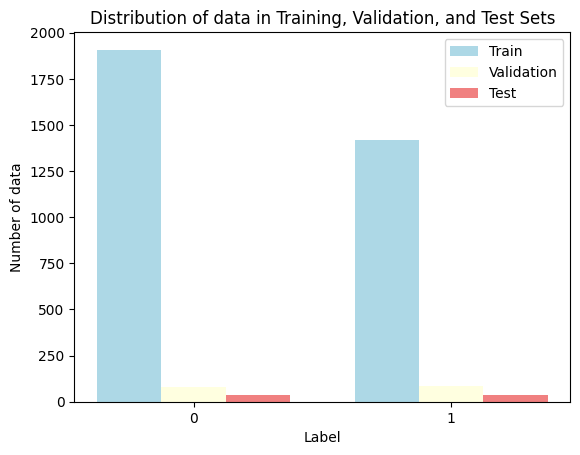

In [15]:
# Counts the number of instances labeled as 'no cancer' in the training set
no_cancer_train = (Y_train == 0).sum()
# Counts the number of instances labeled as 'cancer' in the training set
cancer_train = (Y_train == 1).sum()
# Counts the number of instances labeled as 'no cancer' in the validation set
no_cancer_validation = (Y_validation == 0).sum()
# Counts the number of instances labeled as 'cancer' in the validation set
cancer_validation = (Y_validation == 1).sum()
# Counts the number of instances labeled as 'no cancer' in the test set
no_cancer_test = (Y_test == 0).sum()
# Counts the number of instances labeled as 'cancer' in the test set
cancer_test = (Y_test == 1).sum()

# Defines the values used on the plot
categories = ['0', '1']
train_values = [no_cancer_train, cancer_train]
validation_values = [no_cancer_validation, cancer_validation]
test_values = [no_cancer_test, cancer_test]
bar_width = 0.25
index = np.arange(len(categories))

# Creates a grouped bar plot to visualize the distribution of data in the training, validation, and test sets
plt.bar(index - bar_width, train_values, bar_width, label='Train', color='lightblue')
plt.bar(index, validation_values, bar_width, label='Validation', color='lightyellow')
plt.bar(index + bar_width, test_values, bar_width, label='Test', color='lightcoral')

# Adds legend, title and ticks
plt.title('Distribution of data in Training, Validation, and Test Sets')
plt.ylabel('Number of data')
plt.xlabel('Label')
plt.xticks(index, categories)
plt.legend()

# Displays the plot
plt.show()

In [16]:
print("--- Proportions for training ---")
print(f"No cancer: {(train_values[0] / (train_values[0] + train_values[1])) * 100:.2f}%")
print(f"Cancer: {(train_values[1] / (train_values[0] + train_values[1])) * 100:.2f}%")

print("\n--- Proportions for validation ---")
print(f"No cancer: {(validation_values[0] / (validation_values[0] + validation_values[1])) * 100:.2f}%")
print(f"Cancer: {(validation_values[1] / (validation_values[0] + validation_values[1])) * 100:.2f}%")

print("\n--- Proportions for test ---")
print(f"No cancer: {(test_values[0] / (test_values[0] + test_values[1])) * 100:.2f}%")
print(f"Cancer: {(test_values[1] / (test_values[0] + test_values[1])) * 100:.2f}%")

--- Proportions for training ---
No cancer: 57.31%
Cancer: 42.69%

--- Proportions for validation ---
No cancer: 48.15%
Cancer: 51.85%

--- Proportions for test ---
No cancer: 47.89%
Cancer: 52.11%


The plot shows that I have a balanced dataset.<br>
So, I have balanced subsets group by patients. I also scale the different subsets.<br>
This balance ensures that each label is approximately equaly represented, avoiding overffiting.<br>
Moreover, if samples from the same patient are found in both the training set and the test set, the model may learn to memorize information specific to that patient, rather than learning general features that can be generalized to new patients. This can lead to an overestimation of the model's performance when evaluated on test data.

### MACHINE LEARNING

##### HYPERPARAMETERS AND PARAMETERS TUNING

**Hyperparameters influence the model's ability to adapt to the data.<br>
Adjusting them is crucial to avoid over-fitting, where the model learns specific details from the training data and thus, don't generalize well on unseen data, or under-fitting, where the model is too simplified to catch the structure of the data.**

**Choosing model parameters is also essential. These control the model's ability to represent the relationship between input features X and target output variable Y. <br>
So, choosing the parameters best suited to our model helps minimize error on training data.<br>
This improves overall model performance and generalizability.**

In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

<u>**K-Nearest Neighbors**</u>

The K-Nearest Neighbors for classification works as follow:

- Store all the data points and their corresponding labels;
- Give a new, unseen data point, calculate its distance to all other points in the dataset;
- Identify the K nearest data points (neighbors) to the new data point based on the calculated distances;
- Assign the most common class label among the K nearest neighbors to the new data point.

In [18]:
from sklearn.neighbors import KNeighborsClassifier

In [19]:
# Defines a dictionary containing the hyperparameter values to be tested
parameters_knn = {
    'n_neighbors': range(1, 21),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Initializes a K-Nearest Neighbors classifier
knn_classifier = KNeighborsClassifier()

# Defines the framework for the search for the best hyperparameters
# Specify the model, the hyperparameters to be tested, the cross-validation method, and the metrics to be used to evaluate performance
grid_search_knn = GridSearchCV(knn_classifier, parameters_knn, cv=10, scoring='recall')
# Finds the best possible combination
grid_search_knn.fit(X_train, Y_train)
print(f"Mean cross-validated score of the best estimator for K-Nearest Neighbors: {grid_search_knn.best_score_ * 100:.2f}%")

# Retrieves the best hyperparameters
best_parameters_knn = grid_search_knn.best_params_
print("Best parameters:", best_parameters_knn)

# Builds the final model using the best hyperparameters
final_model_knn = grid_search_knn.best_estimator_

Mean cross-validated score of the best estimator for K-Nearest Neighbors: 58.27%
Best parameters: {'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'}


<u>**Decision Tree**</u>

Decision Tree is a classification method that works as follows:
- We compute the gain of each split;
- The root node of the tree is made with the feature that has the best gain;
- For each subsequent node, the process is repeated: the algorithm evaluates all possible splits on the available features and selects the one with the highest gain;
- This process continues recursively until some stopping criteria are met, such as reaching a maximum depth, minimum number of samples per node;
- Then, to classify a new data point we just have to visit from the root node down to a leaf node based on the feature values of the data point (a decision tree is a set of decision rules);
- Finally, the predicted class for the new data point is then determined by the majority class of the samples in the leaf node it reaches.

In [20]:
from sklearn.tree import DecisionTreeClassifier

In [21]:
# Defines a dictionary containing the hyperparameter values to be tested
parameters_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initializes a Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Defines the framework for the search for the best hyperparameters
# Specify the model, the hyperparameters to be tested, the cross-validation method, and the metrics to be used to evaluate performance
grid_search_dt = GridSearchCV(dt_classifier, parameters_dt, cv=10, scoring='recall')
# Finds the best possible combination
grid_search_dt.fit(X_train, Y_train)
print(f"Mean cross-validated score of the best estimator for Decision Tree: {grid_search_dt.best_score_ * 100:.2f}%")

# Retrieves the best hyperparameters
best_parameters_dt = grid_search_dt.best_params_
print("Best parameters:", best_parameters_dt)

# Builds the final model using the best hyperparameters
final_model_dt = grid_search_dt.best_estimator_

Mean cross-validated score of the best estimator for Decision Tree: 61.50%
Best parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}


<u>**Random Forest**</u>

A random forest is an aggregation of decision trees. The aim is to make the method less sensitive to noise and outliers in the training base.<br>
The goal of a random forest is to build several trees on bootstrap samples of the learning base.<br>
A bootstrap sample is a random draw of elements from the training base:
<center>

  <li>either of n elements with replacement</li>
  <li>or of k < n elements (with or without replacement)</li>

</center>

from the n observations in the training database.

- So, for each bootstrap sample, we build a decision tree;
- Then, we use each to obtain an estimate of the class of the target variable for a new individual;
- The final estimate is made by majority vote;
- Finally, the probability of belonging to a class is calculated by counting the number of times a tree has predicted the class out of the total of trees.

In [22]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Defines a dictionary containing the hyperparameter values to be tested
parameters_rf = {
    'n_estimators': np.arange(10,200,10),
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initializes a Random Forest classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Defines the framework for the search for the best hyperparameters
# Specify the model, the hyperparameters to be tested, the cross-validation method, and the metrics to be used to evaluate performance
random_search_rf = RandomizedSearchCV(rf_classifier, parameters_rf, cv=10, scoring='recall')
# Finds the best possible combination
random_search_rf.fit(X_train, Y_train)
print(f"Mean cross-validated score of the best estimator for Random Forest: {random_search_rf.best_score_ * 100:.2f}%")

# Retrieves the best hyperparameters
best_parameters_rf = random_search_rf.best_params_
print("Best parameters:", best_parameters_rf)

# Builds the final model using the best hyperparameters
final_model_rf = random_search_rf.best_estimator_

Mean cross-validated score of the best estimator for Random Forest: 59.54%
Best parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None, 'bootstrap': False}


<u>**Neural Network**</u>

In this case, I'm using a binary output neural network.<br>
A neural network consists of an input layer corresponding to the features, one or more hidden layers, and an output layer that, in this case, allows us to obtain a probability.

As it passes through the different layers, the features undergo transformations. Each neuron in the hidden layers calculates a weighted sum of its inputs, then applies an activation function to this result.

In a binary output neural network, the output layer consists of a single neuron.<br>
This neuron combines the outputs of the neurons from the last hidden layer and calculates a weighted sum of these values, then applies a special activation function called the sigmoid function.

Once the output of the output layer is calculated using the sigmoid function, this value can be interpreted as the probability.<br>
For example:<br>

- class = 0 if output < 0.5<br>
- class = 1 if output >= 0.5

In [24]:
from sklearn.neural_network import MLPClassifier

In [25]:
# Defines a dictionary containing the hyperparameter values to be tested
parameters_nn = {
    'hidden_layer_sizes': [(100,), (50,), (25,)],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01],
    'warm_start': [True, False],
    'max_iter': np.arange(50,100,10),
    'learning_rate': ['constant', 'invscaling', 'adaptive']
}

# Initializes a Neural Network classifier
nn_classifier = MLPClassifier(random_state=42, max_iter=1000)

# Defines the framework for the search for the best hyperparameters
# Specify the model, the hyperparameters to be tested, the cross-validation method, and the metrics to be used to evaluate performance
random_search_nn = RandomizedSearchCV(nn_classifier, parameters_nn, cv=10, scoring='recall', n_iter=50, random_state=42, n_jobs=-1)
# Finds the best possible combination
random_search_nn.fit(X_train, Y_train)
print(f"Mean cross-validated score of the best estimator for Neural Network: {random_search_nn.best_score_ * 100:.2f}%")

# Retrieves the best hyperparameters
best_parameters_nn = random_search_nn.best_params_
print("Best parameters:", best_parameters_nn)

# Builds the final model using the best hyperparameters
final_model_nn = random_search_nn.best_estimator_

/home/amandine/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (80) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/amandine/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (80) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/amandine/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (80) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/amandine/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (80) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/amandine/.local/lib/python3.10/site-pa

Mean cross-validated score of the best estimator for Neural Network: 71.92%
Best parameters: {'warm_start': False, 'solver': 'sgd', 'max_iter': 70, 'learning_rate': 'invscaling', 'hidden_layer_sizes': (50,), 'alpha': 0.001, 'activation': 'tanh'}


<u>**Naïve Bayes**</u>

The Naive Bayes classifier is based on Bayes' theorem with an assumption of conditional independence between features.

Bayes' theorem is formulated as follows:<br>
$P(y=y_k|x) = \frac{P(x|y=y_k) \times P(y=y_k)}{P(x)}$

For each observation, the model calculates the probability of each class given that observation using Bayes' theorem, and then chooses the class with the highest probability as the prediction.

In [26]:
from sklearn.naive_bayes import GaussianNB

In [27]:
# Defines a dictionary containing the hyperparameter values to be tested
parameters_nb = {'var_smoothing': np.logspace(0, -9, num=100)}

# Initializes a Naïve Bayes classifier
nb_classifier = GaussianNB()

# Defines the framework for the search for the best hyperparameters
# Specify the model, the hyperparameters to be tested, the cross-validation method, and the metrics to be used to evaluate performance
grid_search_nb = GridSearchCV(estimator=nb_classifier, param_grid=parameters_nb, cv=10, verbose=1, scoring='recall')
# Finds the best possible combination
grid_search_nb.fit(X_train, Y_train)
print(f"Mean cross-validated score of the best estimator for Naïve Bayes: {grid_search_nb.best_score_ * 100:.2f}%")

# Retrieves the best hyperparameters
best_parameters_nb = grid_search_nb.best_params_
print("Best parameters:", best_parameters_nb)

# Builds the final model using the best hyperparameters
final_model_nb = grid_search_nb.best_estimator_

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Mean cross-validated score of the best estimator for Naïve Bayes: 57.98%
Best parameters: {'var_smoothing': 0.035111917342151314}


<u>**Logistic Regression**</u>

Like the Naïve Bayes method, logistic regression models the probability that the target variable belongs to a positive class.<br>
To do this, we compute $logit(p(x)) = a_0 + a_1*x_1+a_2*x_2+...+a_p*x_p$<br>
So, $p(x) = \frac{1}{1 + exp(logit(p(x)))}$

In [28]:
from sklearn.linear_model import LogisticRegression

In [29]:
# Defines a dictionary containing the hyperparameter values to be tested
parameters_lr = {
    "C": [0.001, 0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs", "newton-cg"],
    "max_iter": [1000]
}

# Initializes a Logistic Regression classifier
lr = LogisticRegression(random_state=42)

# Defines the framework for the search for the best hyperparameters
# Specify the model, the hyperparameters to be tested, the cross-validation method, and the metrics to be used to evaluate performance
grid_search_lr = GridSearchCV(lr, param_grid=parameters_lr, cv=10, verbose=True, n_jobs=-1, scoring='recall')
# Finds the best possible combination
grid_search_lr.fit(X_train, Y_train)
print(f"Mean cross-validated score of the best estimator for Logistic Regression: {grid_search_lr.best_score_ * 100:.2f}%")

# Retrieves the best hyperparameters
best_parameters_lr = grid_search_lr.best_params_
print("Best parameters:", best_parameters_lr)

# Builds the final model using the best hyperparameters
final_model_lr = grid_search_lr.best_estimator_

Fitting 10 folds for each of 15 candidates, totalling 150 fits
Mean cross-validated score of the best estimator for Logistic Regression: 63.76%
Best parameters: {'C': 1, 'max_iter': 1000, 'solver': 'liblinear'}


<u>**Support Vector Machine**</u>

SVM works by finding the hyperplane (or line is it's a 2D space) that best separates the classes in the feature space.<br>
SVM assumes that the data points of different classes can be separated by an hyperplane with the maximum margin that is the distance between the hyperplane and the nearest data points from each class.<br>
SVM aims to maximize this margin, which leads to better generalization and robustness of the model.

In [30]:
from sklearn.svm import SVC

In [31]:
# Defines a dictionary containing the hyperparameter values to be tested
parameters_svm = {
    'C': [0.001, 0.01, 0.1, 1],
    'gamma': [0.001, 0.0001],
    'kernel': ['linear','rbf']
}

# Initializes a Support Vector Machine classifier
svm_classifier = SVC(probability=True, random_state=42)

# Defines the framework for the search for the best hyperparameters
# Specify the model, the hyperparameters to be tested, the cross-validation method, and the metrics to be used to evaluate performance
grid_search_svm = GridSearchCV(svm_classifier, parameters_svm, cv=10, scoring='recall')
# Finds the best possible combination
grid_search_svm.fit(X_train, Y_train)
print(f"Mean cross-validated score of the best estimator for Support Vector Machine: {grid_search_svm.best_score_ * 100:.2f}%")

# Retrieves the best hyperparameters
best_parameters_svm = grid_search_svm.best_params_
print("Best parameters found:", best_parameters_svm)

# Builds the final model using the best hyperparameters
final_model_svm = grid_search_svm.best_estimator_

Mean cross-validated score of the best estimator for Support Vector Machine: 59.96%
Best parameters found: {'C': 1, 'gamma': 0.001, 'kernel': 'linear'}


##### MODEL SELECTION

To select our model, the on corresponding the best to our needs, we use the validation set and **NEVER USE THE TEST SET**.<br>
I chose the model with the best accuracy score, F1 score, recall score and AUC (Area Under teh Curve).<br>
The higher their values, the better the model.

In [32]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

In [33]:
# Predicts the labels for the validation set using the final K-Nearest Neighbors model
Y_validation_pred_knn = final_model_knn.predict(X_validation)
# Calculates the accuracy score for the validation set
accuracy_validation_knn = accuracy_score(Y_validation, Y_validation_pred_knn)
print(f"Accuracy on Validation set: {accuracy_validation_knn * 100:.2f}%")
f1_knn = f1_score(Y_validation, Y_validation_pred_knn)
print(f"F1-score on Validation set: {f1_knn * 100:.2f}%")
recall_knn = recall_score(Y_validation, Y_validation_pred_knn)
print(f"Recall on Validation set: {recall_knn * 100:.2f}%")

Accuracy on Validation set: 70.99%
F1-score on Validation set: 73.14%
Recall on Validation set: 76.19%


In [34]:
# Predicts the labels for the validation set using the final Decision Tree model
Y_validation_pred_dt = final_model_dt.predict(X_validation)
# Calculates the accuracy score for the validation set
accuracy_validation_dt = accuracy_score(Y_validation, Y_validation_pred_dt)
print(f"Accuracy on Validation set: {accuracy_validation_dt * 100:.2f}%")
f1_dt = f1_score(Y_validation, Y_validation_pred_dt)
print(f"F1-score on Validation set: {f1_dt * 100:.2f}%")
recall_dt = recall_score(Y_validation, Y_validation_pred_dt)
print(f"Recall on Validation set: {recall_dt * 100:.2f}%")

Accuracy on Validation set: 70.99%
F1-score on Validation set: 73.74%
Recall on Validation set: 78.57%


In [35]:
# Predicts the labels for the validation set using the final Random Forest model
Y_validation_pred_rf = final_model_rf.predict(X_validation)
# Calculates the accuracy score for the validation set
accuracy_validation_rf = accuracy_score(Y_validation, Y_validation_pred_rf)
print(f"Accuracy on Validation set: {accuracy_validation_rf * 100:.2f}%")
f1_rf = f1_score(Y_validation, Y_validation_pred_rf)
print(f"F1-score on Validation set: {f1_rf * 100:.2f}%")
recall_rf = recall_score(Y_validation, Y_validation_pred_rf)
print(f"Recall on Validation set: {recall_rf * 100:.2f}%")

Accuracy on Validation set: 79.01%
F1-score on Validation set: 79.52%
Recall on Validation set: 78.57%


In [36]:
# Predicts the labels for the validation set using the final Neural Network model
Y_validation_pred_nn = final_model_nn.predict(X_validation)
# Calculates the accuracy score for the validation set
accuracy_validation_nn = accuracy_score(Y_validation, Y_validation_pred_nn)
print(f"Accuracy on Validation set: {accuracy_validation_nn * 100:.2f}%")
f1_nn = f1_score(Y_validation, Y_validation_pred_nn)
print(f"F1-score on Validation set: {f1_nn * 100:.2f}%")
recall_nn = recall_score(Y_validation, Y_validation_pred_nn)
print(f"Recall on Validation set: {recall_nn * 100:.2f}%")

Accuracy on Validation set: 53.70%
F1-score on Validation set: 63.41%
Recall on Validation set: 77.38%


In [37]:
# Predicts the labels for the validation set using the final Naïve Bayes model
Y_validation_pred_nb = final_model_nb.predict(X_validation)
# Calculates the accuracy score for the validation set
accuracy_validation_nb = accuracy_score(Y_validation, Y_validation_pred_nb)
print(f"Accuracy on Validation set: {accuracy_validation_nb * 100:.2f}%")
f1_nb = f1_score(Y_validation, Y_validation_pred_nb)
print(f"F1-score on Validation set: {f1_nb * 100:.2f}%")
recall_nb = recall_score(Y_validation, Y_validation_pred_nb)
print(f"Recall on Validation set: {recall_nb * 100:.2f}%")

Accuracy on Validation set: 46.91%
F1-score on Validation set: 54.74%
Recall on Validation set: 61.90%


In [38]:
# Predicts the labels for the validation set using the final Logistic Regression model
Y_validation_pred_lr = final_model_lr.predict(X_validation)
# Calculates the accuracy score for the validation set
accuracy_validation_lr = accuracy_score(Y_validation, Y_validation_pred_lr)
print(f"Accuracy on Validation set: {accuracy_validation_lr * 100:.2f}%")
f1_lr = f1_score(Y_validation, Y_validation_pred_lr)
print(f"F1-score on Validation set: {f1_lr * 100:.2f}%")
recall_lr = recall_score(Y_validation, Y_validation_pred_lr)
print(f"Recall on Validation set: {recall_lr * 100:.2f}%")

Accuracy on Validation set: 75.31%
F1-score on Validation set: 75.00%
Recall on Validation set: 71.43%


In [39]:
# Predicts the labels for the validation set using the final Support Vector Machine model
Y_validation_pred_svm = final_model_svm.predict(X_validation)
# Calculates the accuracy score for the validation set
accuracy_validation_svm = accuracy_score(Y_validation, Y_validation_pred_svm)
print(f"Accuracy on Validation set: {accuracy_validation_svm * 100:.2f}%")
f1_svm = f1_score(Y_validation, Y_validation_pred_svm)
print(f"F1-score on Validation set: {f1_svm * 100:.2f}%")
recall_svm = recall_score(Y_validation, Y_validation_pred_svm)
print(f"Recall on Validation set: {recall_svm * 100:.2f}%")

Accuracy on Validation set: 76.54%
F1-score on Validation set: 75.64%
Recall on Validation set: 70.24%


In [40]:
from sklearn.metrics import roc_curve, auc

In [41]:
# Calculates the ROC curve and the AUC score for the K-Nearest Neighbors model
fpr_knn, tpr_knn, thresholds_knn = roc_curve(Y_validation, final_model_knn.predict_proba(X_validation)[:, 1])
roc_auc_knn = auc(fpr_knn, tpr_knn)

# Calculates the ROC curve and the AUC score for the Decision Tree model
fpr_dt, tpr_dt, thresholds_dt = roc_curve(Y_validation, final_model_dt.predict_proba(X_validation)[:, 1])
roc_auc_dt = auc(fpr_dt, tpr_dt)

# Calculates the ROC curve and the AUC score for the Random Forest model
fpr_rf, tpr_rf, thresholds_rf = roc_curve(Y_validation, final_model_rf.predict_proba(X_validation)[:, 1])
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Calculates the ROC curve and the AUC score for the Neural Network model
fpr_nn, tpr_nn, thresholds_nn = roc_curve(Y_validation, final_model_nn.predict_proba(X_validation)[:, 1])
roc_auc_nn = auc(fpr_nn, tpr_nn)

# Calculates the ROC curve and the AUC score for the Naïve Bayes model
fpr_nb, tpr_nb, thresholds_nb = roc_curve(Y_validation, final_model_nb.predict_proba(X_validation)[:, 1])
roc_auc_nb = auc(fpr_nb, tpr_nb)

# Calculates the ROC curve and the AUC score for the Logistic Regression model
fpr_lr, tpr_lr, thresholds_lr = roc_curve(Y_validation, final_model_lr.predict_proba(X_validation)[:, 1])
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Calculates the ROC curve and the AUC score for the Support Vector Machine model
fpr_svm, tpr_svm, thresholds_svm = roc_curve(Y_validation, final_model_svm.predict_proba(X_validation)[:, 1])
roc_auc_svm = auc(fpr_svm, tpr_svm)

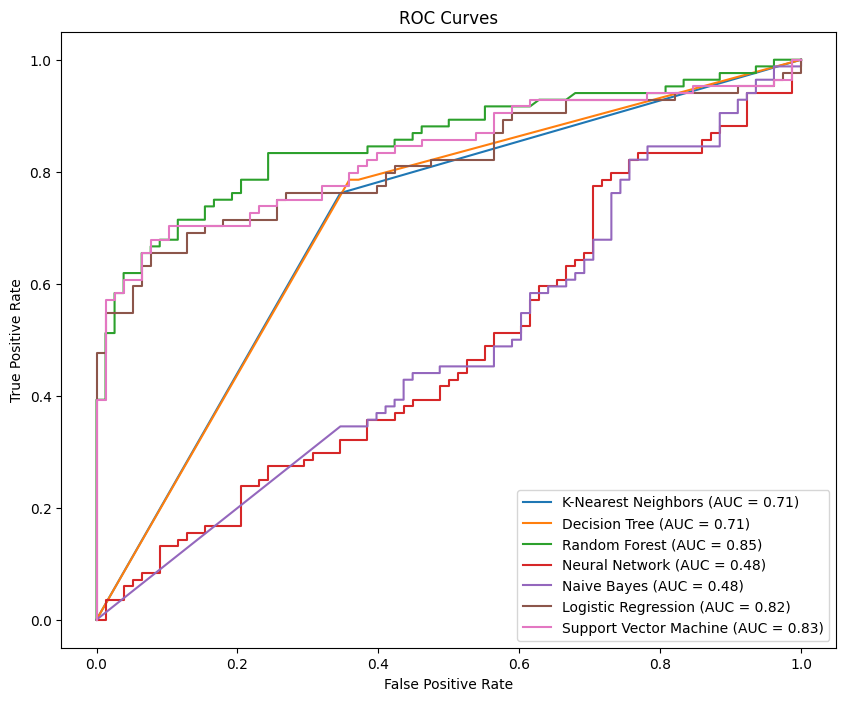

In [42]:
# Initializes the plot dimensions
plt.figure(figsize=(10, 8))

# Plotting the ROC curve for the all models
plt.plot(fpr_knn, tpr_knn, label='K-Nearest Neighbors (AUC = %0.2f)' % roc_auc_knn)
plt.plot(fpr_dt, tpr_dt, label='Decision Tree (AUC = %0.2f)' % roc_auc_dt)
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = %0.2f)' % roc_auc_rf)
plt.plot(fpr_nn, tpr_nn, label='Neural Network (AUC = %0.2f)' % roc_auc_nn)
plt.plot(fpr_nb, tpr_nb, label='Naive Bayes (AUC = %0.2f)' % roc_auc_nb)
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression (AUC = %0.2f)' % roc_auc_lr)
plt.plot(fpr_svm, tpr_svm, label='Support Vector Machine (AUC = %0.2f)' % roc_auc_svm)

# Adds legend and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')

# Displays the plot
plt.show()

In [43]:
# Creates a dictionary containing accuracy scores for all models on the validation set
metrics = {
    'Accuracy on Validation set': [accuracy_validation_knn, accuracy_validation_dt, accuracy_validation_rf, accuracy_validation_nn, accuracy_validation_nb, accuracy_validation_lr, accuracy_validation_svm],
    'F1-Score': [f1_knn, f1_dt, f1_rf, f1_nn, f1_nb, f1_lr, f1_svm],
    'Recall': [recall_knn, recall_dt, recall_rf, recall_nn, recall_nb, recall_lr, recall_svm],
    'AUC': [roc_auc_knn, roc_auc_dt, roc_auc_rf, roc_auc_nn, roc_auc_nb, roc_auc_lr, roc_auc_svm]
}

# Creates a dataframe from the metrics dictionary
metrics_df = pd.DataFrame(metrics, index=['K-Nearest Neighbors', 'Decision Tree', 'Random Forest', 'Neural Network', 'Naive Bayes', 'Logistic Regression', 'Support Vector Machine'], columns=['Accuracy on Validation set', 'F1-Score', 'Recall', 'AUC'])
# Sorts the dataframe
sorted_metrics_df = metrics_df.sort_values(by=['Accuracy on Validation set', 'F1-Score', 'Recall', 'AUC'], ascending=[False, False, False, False])
sorted_metrics_df

,Accuracy on Validation set,F1-Score,Recall,AUC
Random Forest,0.790123,0.795181,0.785714,0.854853
Support Vector Machine,0.765432,0.756410,0.702381,0.830739
Logistic Regression,0.753086,0.750000,0.714286,0.815476
Decision Tree,0.709877,0.737430,0.785714,0.711996
K-Nearest Neighbors,0.709877,0.731429,0.761905,0.707875
Neural Network,0.537037,0.634146,0.773810,0.482753
Naive Bayes,0.469136,0.547368,0.619048,0.484509


In [44]:
# Retrieve the name of the best model = the first row
best_model_name = sorted_metrics_df.index[0]
print("Name of the best model:", best_model_name)

Name of the best model: Random Forest


In [45]:
if best_model_name == 'Random Forest':
  final_model = final_model_rf

if best_model_name == 'Support Vector Machine':
  final_model = final_model_svm

if best_model_name == 'Logistic Regression':
  final_model = final_model_lr

if best_model_name == 'Decision Tree':
  final_model = final_model_dt

if best_model_name == 'K-Nearest Neighbors':
  final_model = final_model_knn

if best_model_name == 'Neural Network':
  final_model = final_model_nn

if best_model_name == 'Naive Bayes':
  final_model = final_model_nb

<u>**Accuracy:**</u> is used to assess the overall quality of the model.<br>
The higher its value, the better the model's predictions.<br>
$$ \text{accuracy} = \frac{\text{number of correct predictions}}{\text{number of total samples}} $$

<u>**F1-score:**</u> a performance measure that takes precision and recall into account (particularly useful when classes are unbalanced).
$$ \text{F1-score} = \frac{2 * \text{precision} * \text{recall}}{\text{precision} + \text{recall}} $$

<u>**Recall:**</u> a performance measure that ensures that the majority of positive cases
are detected.
$$ \text{recall} = \frac{\text{true positive}}{\text{true positive + false negative}} $$

In the medical context, false negatives (i.e. cases where a model predicts that a person does not have
the disease when they actually do) can have serious consequences. A false negative can result in a
lack of timely and appropriate treatment, which can worsen the patient’s condition or even be fatal.
This is why having a high recall is important.

<u>**AUC:**</u> used to evaluate the quality of a binary classification model.<br>
It's a graph representing the true positive rate as a function of the false positive rate.<br>
A high AUC indicates a better ability of the model to distinguish between positive and negative classes.<br>
The AUC varies from 0 to 1, where a higher value indicates better performance. An AUC of 1 means that the model predicts class labels perfectly, while an AUC of 0.5 means that the model predicts class labels at random.

**Finally, here, the best model seems to be the <u>Random Forest</u> one.**

##### EVALUTE THE CHOSEN MODEL PERFORMANCE

To find out how the model performs, we need to use the test set.<br>
This means that we use unseen data, enabling us to assess the model's ability to generalize.

In [46]:
# Predicts the labels for the test set using the final Neural Network model
Y_test_pred_final = final_model.predict(X_test)
# Calculates the accuracy score for the test set
accuracy_test_final = accuracy_score(Y_test, Y_test_pred_final)
print(f"Accuracy on Test set: {accuracy_test_final * 100:.2f}%")

Accuracy on Test set: 76.06%


In [47]:
from sklearn.metrics import confusion_matrix

In [48]:
conf_matrix_test_final = confusion_matrix(Y_test, Y_test_pred_final)
conf_matrix_test_df_final = pd.DataFrame(
    conf_matrix_test_final,
    index=["No Cancer", "Cancer"],
    columns=["Predicted No Cancer", "Predicted Cancer"]
)
print("\nConfusion Matrix (Test Set):")
conf_matrix_test_df_final


Confusion Matrix (Test Set):


,Predicted No Cancer,Predicted Cancer
No Cancer,25,9
Cancer,8,29


In [49]:
from sklearn.metrics import precision_score

In [50]:
precision_final = precision_score(Y_test, Y_test_pred_final)
recall_final = recall_score(Y_test, Y_test_pred_final)
f1_final = f1_score(Y_test, Y_test_pred_final)

print(f"Precision (proportion of positive predicted for which the class is correct): {precision_final * 100:.2f}%")
print(f"Recall (proportion of data in the positive class for which the prediction is correct): {recall_final * 100:.2f}%")
print(f"F1-score: {f1_final * 100:.2f}%")

Precision (proportion of positive predicted for which the class is correct): 76.32%
Recall (proportion of data in the positive class for which the prediction is correct): 78.38%
F1-score: 77.33%


<u>**Interpretation**</u>

**I obtained an accuracy of 76.06% on the test set.
Moreover, the recall that is really important in the health area is around 78.38%. That's good because it represents the ability to capture false positive.**

**Thus, the model performed quite well in the prediction of non-cancerous samples, with 25 correct predictions and 9 false predictions, and of cancerous samples, with 29 correct predictions and 8 false predictions.**

**Overall, the model is satisfactory. It seems to generalize the data correctly.**

### FEATURES SELECTION

In [51]:
import random

In [52]:
# Define the number of random combinations and the number of features to select
n_combinations = 100
n_features = 10

# Store the best score and the best feature combination
best_score = 0
best_combination = None

# Randomly select combinations of features and evaluate them
for _ in range(n_combinations):
    # Randomly select n_features from the total features
    selected_features = random.sample(list(X.columns), n_features)

    # Subset the data to these features
    X_train_selected = train_df[selected_features]
    X_val_selected = val_df[selected_features]
    X_test_selected = test_df[selected_features]

    # Subset scaling
    scaler_features = StandardScaler()
    X_train_selected = scaler_features.fit_transform(X_train_selected)
    X_val_selected = scaler_features.transform(X_val_selected)
    X_test_selected = scaler_features.transform(X_test_selected)

    # Train the model
    model = RandomForestClassifier(random_state=0)
    model.fit(X_train_selected, Y_train)

    # Predict on the validation set
    Y_val_pred = model.predict(X_val_selected)
    # Evaluate the model
    val_score = accuracy_score(Y_validation, Y_val_pred)

    # Update the best score and combination if the current one is better
    if val_score > best_score:
        best_score = val_score
        best_combination = selected_features
        best_X_train = X_train_selected
        best_X_val = X_val_selected
        best_X_test = X_test_selected

In [53]:
print(f"The best features combination (10 features) is: {best_combination}")

The best features combination (10 features) is: ['wavelet2-LLH_glrlm_RunVariance', 'wavelet-LLL_glszm_LargeAreaLowGrayLevelEmphasis', 'wavelet-LLH_glrlm_LongRunLowGrayLevelEmphasis', 'wavelet-HHL_glrlm_RunPercentage', 'wavelet2-LHL_glrlm_GrayLevelNonUniformityNormalized', 'wavelet-LHH_firstorder_InterquartileRange', 'original_glrlm_LowGrayLevelRunEmphasis', 'wavelet2-LLH_gldm_LargeDependenceEmphasis', 'log-sigma-3-0-mm-3D_glrlm_ShortRunEmphasis', 'wavelet-LHH_firstorder_RootMeanSquared']


In [54]:
# Defines a dictionary containing the hyperparameter values to be tested
parameters_rf = {
    'n_estimators': np.arange(10,200,10),
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initializes a Random Forest classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Defines the framework for the search for the best hyperparameters
# Specify the model, the hyperparameters to be tested, the cross-validation method, and the metrics to be used to evaluate performance
random_search_rf = RandomizedSearchCV(rf_classifier, parameters_rf, cv=10, scoring='recall')
# Finds the best possible combination
random_search_rf.fit(best_X_train, Y_train)
print(f"Mean cross-validated score of the best estimator for Random Forest: {random_search_rf.best_score_ * 100:.2f}%")

# Retrieves the best hyperparameters
best_parameters_rf = random_search_rf.best_params_
print("Best parameters:", best_parameters_rf)

# Builds the final model using the best hyperparameters
final_model_rf = random_search_rf.best_estimator_

Mean cross-validated score of the best estimator for Random Forest: 54.54%
Best parameters: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None, 'bootstrap': True}


In [55]:
# Predicts the labels for the validation set using the final Random Forest model
Y_validation_pred_rf_final = final_model_rf.predict(best_X_val)
# Calculates the accuracy score for the validation set
accuracy_validation_rf_final = accuracy_score(Y_validation, Y_validation_pred_rf_final)
print(f"Accuracy on Validation set: {accuracy_validation_rf_final * 100:.2f}%")
f1_rf_final = f1_score(Y_validation, Y_validation_pred_rf_final)
print(f"F1-score on Validation set: {f1_rf_final * 100:.2f}%")
recall_rf_final = recall_score(Y_validation, Y_validation_pred_rf_final)
print(f"Recall on Validation set: {recall_rf_final * 100:.2f}%")

Accuracy on Validation set: 77.78%
F1-score on Validation set: 78.57%
Recall on Validation set: 78.57%


In [56]:
# Predicts the labels for the test set using the final Neural Network model
Y_test_pred_final = final_model_rf.predict(best_X_test)
# Calculates the accuracy score for the test set
accuracy_test_final = accuracy_score(Y_test, Y_test_pred_final)
print(f"Accuracy on Test set: {accuracy_test_final * 100:.2f}%")

Accuracy on Test set: 74.65%


In [57]:
conf_matrix_test_final = confusion_matrix(Y_test, Y_test_pred_final)
conf_matrix_test_df_final = pd.DataFrame(
    conf_matrix_test_final,
    index=["No Cancer", "Cancer"],
    columns=["Predicted No Cancer", "Predicted Cancer"]
)
print("\nConfusion Matrix (Test Set):")
conf_matrix_test_df_final


Confusion Matrix (Test Set):


,Predicted No Cancer,Predicted Cancer
No Cancer,25,9
Cancer,9,28


In [58]:
precision_final = precision_score(Y_test, Y_test_pred_final)
recall_final = recall_score(Y_test, Y_test_pred_final)
f1_final = f1_score(Y_test, Y_test_pred_final)

print(f"Precision (proportion of positive predicted for which the class is correct): {precision_final * 100:.2f}%")
print(f"Recall (proportion of data in the positive class for which the prediction is correct): {recall_final * 100:.2f}%")
print(f"F1-score: {f1_final * 100:.2f}%")

Precision (proportion of positive predicted for which the class is correct): 75.68%
Recall (proportion of data in the positive class for which the prediction is correct): 75.68%
F1-score: 75.68%


---
## TASK 2: Predict patient's label
---

**To predict the patient's label, i.e. whether the patient has cancer or not, I retrieve all the micros for this patient.<br>
For each of these micros, I predict the class with my chosen model.<br>
Then I take a majority vote on the patient's label.<br>
That's how I get my patient's label.**

In [59]:
new_data = data[best_combination]
new_data = pd.concat([data['Patient ID'], new_data, data['Label']], axis=1)

In [60]:
groups = new_data.groupby('Patient ID')

all_labels = []
all_predictions = []

for patient_id, patient_data in groups:
    X_patient = patient_data.drop(columns=['Patient ID', 'Label'])
    X_patient = scaler_features.fit_transform(X_patient)
    Y_patient = patient_data['Label']

    all_labels.append(majority_vote(Y_patient))

    predicted_labels = final_model_rf.predict(X_patient)
    all_predictions.append(majority_vote(predicted_labels))

In [61]:
# Calculates the accuracy score
final_accuracy = accuracy_score(all_labels, all_predictions)
print(f"Overall accuracy: {final_accuracy * 100:.2f}%")

Overall accuracy: 61.46%


In [62]:
final_conf_matrix = confusion_matrix(all_labels, all_predictions)
final_conf_matrix_df = pd.DataFrame(
    final_conf_matrix,
    index=["No Cancer", "Cancer"],
    columns=["Predicted No Cancer", "Predicted Cancer"]
)
print("\nConfusion Matrix (Test Set):")
final_conf_matrix_df


Confusion Matrix (Test Set):


,Predicted No Cancer,Predicted Cancer
No Cancer,32,14
Cancer,23,27


In [63]:
precision = precision_score(all_labels, all_predictions)
recall = recall_score(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions)
accuracy = accuracy_score(all_labels, all_predictions)

print(f"Precision (proportion of positive predicted for which the class is correct): {precision * 100:.2f}%")
print(f"Recall (proportion of data in the positive class for which the prediction is correct): {recall * 100:.2f}%")
print(f"F1-score: {f1 * 100:.2f}%")
print(f"Overall Accuracy: {accuracy * 100:.2f}%")

Precision (proportion of positive predicted for which the class is correct): 65.85%
Recall (proportion of data in the positive class for which the prediction is correct): 54.00%
F1-score: 59.34%
Overall Accuracy: 61.46%


<u>**Correlation matrix**</u>

- True Positives: 27 => correctly predicted cancer cases
- True Negatives: 32 => correctly predicted non-cancer cases
- False Positives: 14 => non-cancer cases incorrectly predicted as having cancer
- False Negatives: 23 => cancer cases incorrectly predicted as having no cancer

<br>


<u>Accuracy = 61.46%:</u> this model performs well overall, but there's still room for improvement, since in cancer prediction, an error can have serious consequences.

<u>Precision = 65.85%:</u> the precision score is relatively high, meaning that of the cases predicted to be cancer, around 66% are actually cancer cases. This performance is quite good.

<u>Recall = 54.00%:</u> the recall score is lower, indicating that the model fails to correctly identify 48% of cancer cases (false negatives). This metrics is to improve.<br>
Oversampling, i.e. increasing the number of positive samples in the training set (e.g. using SMOTE), may be necessary.<br>
Under-sampling, i.e. reducing the number of negative cases, could also be tried.

<u>F1-score = 59.34%:</u> the F1-score shows a compromise between precision and recall. Here, the result is satisfactory, but a higher F1-score would be desirable to ensure better detection of positive cases while limiting false positives.